In [ ]:
import torch
import numpy as np
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation
from tqdm import tqdm
image_path = "/home/ubuntu/work/satellite_data/digital_orthophoto_nrw/2021/2021/dop10rgbi_32_280_5652_1_nw_2021.tif"
device = 'cuda' if torch.cuda.is_available() else 'cpu'



In [2]:
# # online
# model_id = "restor/tcd-segformer-mit-b2"
# processor = AutoImageProcessor.from_pretrained(model_id)
# model = SegformerForSemanticSegmentation.from_pretrained(model_id).to(device)


In [3]:
# offline
model_path = "./local_tcd-segformer_local"
processor = AutoImageProcessor.from_pretrained(model_path, local_files_only=True)
model = SegformerForSemanticSegmentation.from_pretrained(model_path, local_files_only=True).to(device)

In [4]:
def read_rgb(src, window=None, scale_16bit=True):
  # read rgb bands in satellite img.
  img = src.read([1,2,3], window=window)
  # Move channel axis to last dimension: (H, W, 3)
  img = np.moveaxis(img, 0, -1)
  if scale_16bit and img.dtype == np.uint16:
    img = (img / 256).astype(np.uint8)
  return img

In [5]:
patch_size = 1024 
with rasterio.open(image_path) as src:
    overlap = 128
    stride = patch_size - overlap
    # Sliced Inference
    h, w = src.height, src.width
    full_mask = np.zeros((h, w), dtype=np.uint8)
    windows = [(Window(x, y, min(patch_size, w - x), min(patch_size, h - y)), x, y,)
                for y in range(0, h, stride)
                for x in range(0, w, stride)
                ]

    # testing prints
    print(f"starting tiled inference on {image_path}")
    # processing of each patches
    for window, x, y in tqdm(windows, desc="Inference...", unit="patch"):
        patch = read_rgb(src, window=window)
        # run model inference
        inputs = processor(images=patch, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        #  upsampling back to full mask
        mask = torch.nn.functional.interpolate(logits, size=(window.height, window.width), mode="bilinear")
        full_mask[y: y + window.height, x: x + window.width] = (mask.argmax(dim=1)[0].cpu().numpy() == 1).astype(np.uint8)

    full_img = read_rgb(src, window=None)

starting tiled inference on /home/ubuntu/work/satellite_data/digital_orthophoto_nrw/2021/2021/dop10rgbi_32_280_5652_1_nw_2021.tif


Inference...: 100%|██████████| 144/144 [00:18<00:00,  7.73patch/s]


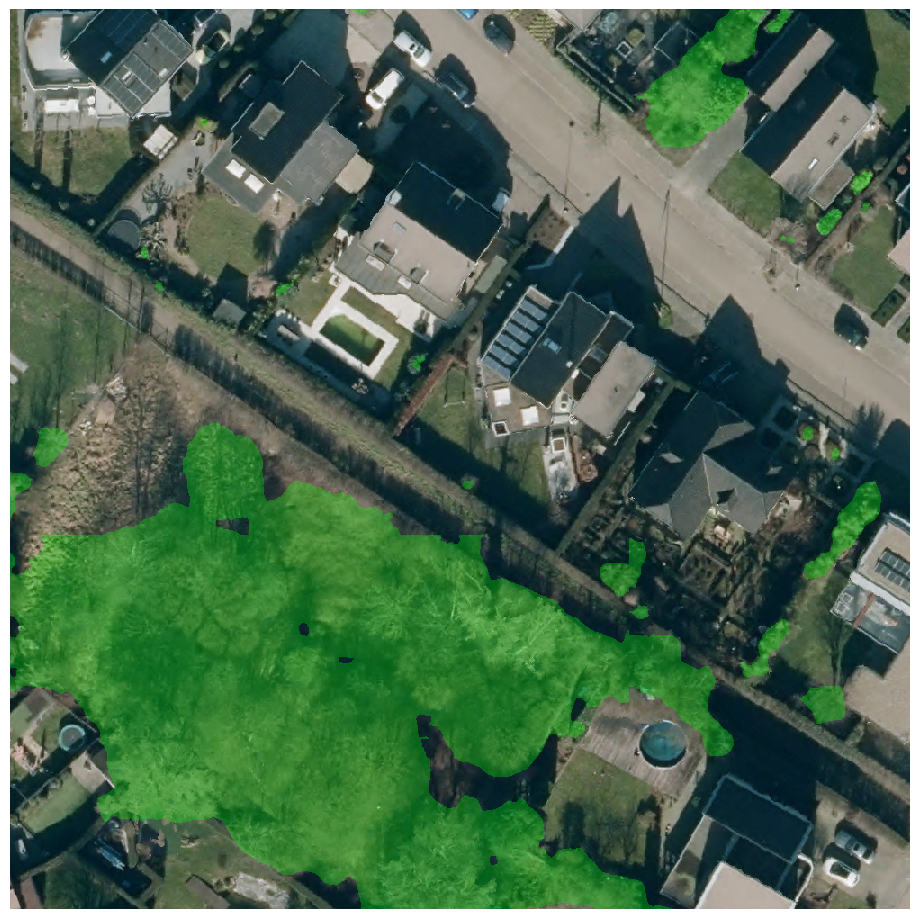

In [20]:
# region to plot among the 10000x10000 image
x_start, x_end = 2000, 3000  
y_start, y_end = 3000, 4000 


# Crop mask and img accordingly
crop_img = full_img[y_start:y_end, x_start:x_end]
crop_mask = full_mask[y_start:y_end, x_start:x_end]

# Create overlay for cropped region 
overlay = crop_img.copy()
overlay[crop_mask == 1] = [0, 255, 0] # ==> positives represented as green
crop_result = (crop_img * 0.7 + overlay * 0.3).astype(np.uint8)

# Plot region 
fig = plt.figure(figsize=(9, 9))
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
ax.imshow(crop_result, interpolation='nearest')
# fig.savefig("cropped_tree_detection.png", dpi=1000, bbox_inches='tight', pad_inches=0)
# plt.close(fig)
plt.show()

In [ ]:
import numpy as np
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

def segment_trees_from_mask(binary_mask: np.ndarray, min_distance: int = 5) -> np.ndarray:
    mask = binary_mask.astype(bool) # for type safety => should be a boolean mask

    # Compute the distance transform
    distance = ndi.distance_transform_edt(mask) 

    # Find local maxima (tree tops) within the mask
    # The `exclude_border` prevents peaks at the very edge
    coordinates = peak_local_max(
        distance,
        min_distance=min_distance,
        exclude_border=False,
        labels=mask
    )

    # Create a marker array (1 for each peak local max)
    markers = np.zeros_like(distance, dtype=int)
    for i, (x, y) in enumerate(coordinates, start=1):
        markers[x, y] = i

    # Apply watershed on the negative distance transform
    # The watershed will split the mask along the ridges of the distance map
    labels = watershed(
        -distance,           # Inverted distance map
        markers=markers,
        mask=mask,
        compactness=0.1 
    )

    return labels.astype(np.uint16)

In [ ]:
tree_labels = segment_trees_from_mask(full_mask, min_distance=5)
# plot_tree_segmentation(full_img, tree_labels)

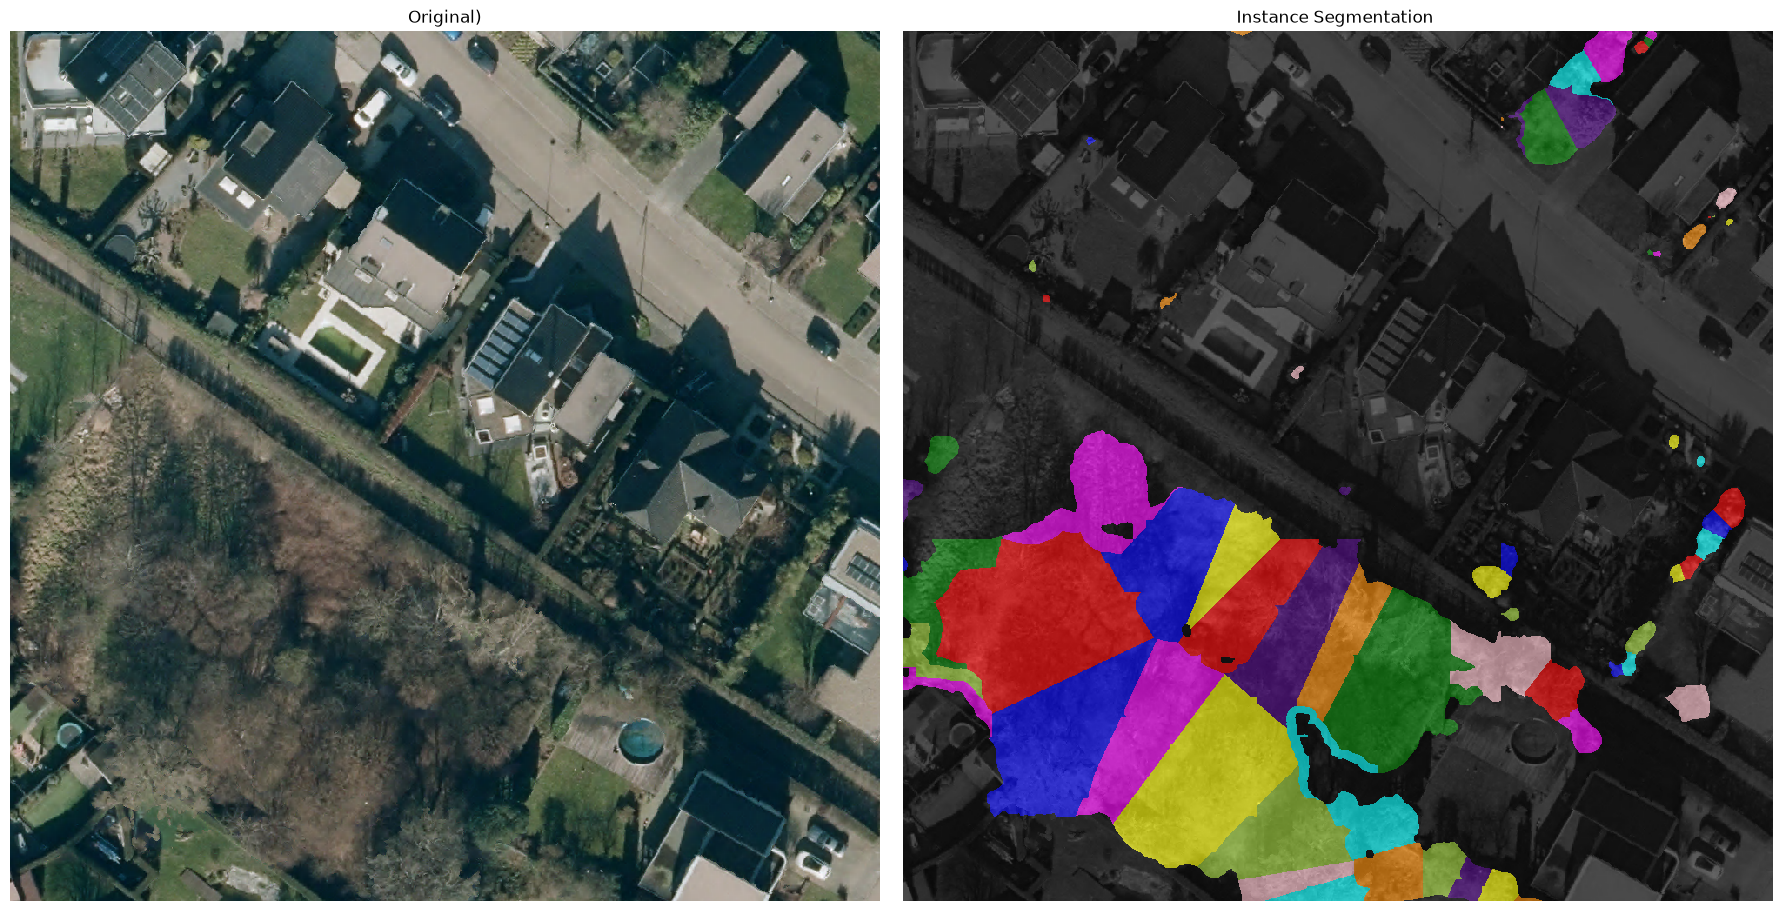

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.color import label2rgb

# Region to crop from the 10000x10000 image
x_start, x_end = 2000, 3000  
y_start, y_end = 3000, 4000 

# Crop full image and masks
crop_img = full_img[y_start:y_end, x_start:x_end]
crop_mask = full_mask[y_start:y_end, x_start:x_end]           # Original binary mask
crop_labels = tree_labels[y_start:y_end, x_start:x_end]       # Instance labels from watershed


# Convert labels to RGB with unique colors per tree
colored_labels = label2rgb(
    crop_labels,
    image=crop_img,         
    bg_label=0,              
    alpha=0.6,               
    kind='overlay'           
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

axes[0].imshow(crop_img, interpolation='nearest')
axes[0].set_title(f"Original)")
axes[0].set_axis_off()

axes[1].imshow(colored_labels, interpolation='nearest')
axes[1].set_title(f"Instance Segmentation ")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## Convert to GeoJSON

In [ ]:
import geopandas as gpd
from rasterio.features import shapes
from shapely.geometry import shape
from rasterio.transform import from_bounds


# model_inference_func unused for now, as mask defined above.
def bbox_to_tree_geojson(bbox_coords, mask, model_inference_func=None):
    min_lon, min_lat, max_lon, max_lat = bbox_coords

    """
    mask = model_inference_func(img, ...) 
    """


    height, width = mask.shape
    
    transform = from_bounds(min_lon, min_lat, max_lon, max_lat, width, height)
    
    results = []
    for geom, value in shapes(mask, mask=(mask == 1), transform=transform):
        results.append({
            "geometry": shape(geom),
            "properties": {"class": "tree", "area_m2": None}
        })
    
    if not results:
        return {"type": "FeatureCollection", "features": []}
    
    gdf = gpd.GeoDataFrame.from_features(results, crs="EPSG:4326")
    gdf_projected = gdf.to_crs("EPSG:3857")
    gdf["area_m2"] = gdf_projected.geometry.area
    
    return gdf

result = bbox_to_tree_geojson((7.615, 51.955, 7.625, 51.965), full_mask)

In [ ]:
result

,geometry,class,area_m2
0,"POLYGON ((7.62284 51.9649, 7.62284 51.9649, 7....",tree,0.185378
1,"POLYGON ((7.62364 51.96487, 7.62364 51.96487, ...",tree,0.074151
2,"POLYGON ((7.6218 51.96487, 7.6218 51.96486, 7....",tree,0.111227
3,"POLYGON ((7.62178 51.96486, 7.62178 51.96485, ...",tree,0.111227
4,"POLYGON ((7.6212 51.96485, 7.6212 51.96485, 7....",tree,11.029996
...,...,...,...
2237,"POLYGON ((7.61643 51.9551, 7.61643 51.9551, 7....",tree,0.759885
2238,"POLYGON ((7.61602 51.95508, 7.61602 51.95508, ...",tree,1.983113
2239,"POLYGON ((7.61674 51.95511, 7.61674 51.95511, ...",tree,27.800660
2240,"POLYGON ((7.6159 51.9551, 7.6159 51.9551, 7.61...",tree,61.476491
